# SL-CBM Multi-Seed Results — CUB & AwA2

In [1]:
import torch
import numpy as np
import pandas as pd

BASE = "/home/dani00003/sl-cbm/outputs"

CUB_SEEDS  = [42, 55, 27, 32, 7]
AWA2_SEEDS = [42, 55, 27]

def load_seed(exp_name):
    d = f"{BASE}/{exp_name}/evaluations"
    result = {}
    try:
        acc = torch.load(f"{d}/accuracy.pt", map_location="cpu")
        result["class_acc"]   = float(acc["test_acc"])
        result["concept_acc"] = float(acc["test_concept_acc"])
    except FileNotFoundError:
        print(f"  [MISSING] accuracy.pt — {exp_name}")
        return None
    try:
        nec = torch.load(f"{d}/nec.pt", map_location="cpu")
        result["nec5"] = float(nec.get("nec5", nec.get("NEC-5", 0)))
        result["anec"] = float(nec.get("anec", nec.get("ANEC",  0)))
    except FileNotFoundError:
        print(f"  [MISSING] nec.pt — {exp_name}")
        result["nec5"] = result["anec"] = None
    try:
        adi = torch.load(f"{d}/adi_pack.pt", map_location="cpu")
        result["concept_ad"] = round(float(adi["concepts_avg_drop"]) * 100, 2)
        result["concept_ai"] = round(float(adi["concepts_avg_inc"])  * 100, 2)
        result["concept_ag"] = round(float(adi["concepts_avg_gain"]) * 100, 2)
        result["class_ad"]   = round(float(adi["classes_avg_drop"])  * 100, 2)
        result["class_ai"]   = round(float(adi["classes_avg_inc"])   * 100, 2)
        result["class_ag"]   = round(float(adi["classes_avg_gain"])  * 100, 2)
    except FileNotFoundError:
        print(f"  [MISSING] adi_pack.pt — {exp_name}")
        for k in ["concept_ad","concept_ai","concept_ag","class_ad","class_ai","class_ag"]:
            result[k] = None
    return result

print("Loading CUB seeds...")
cub_results  = [load_seed(f"slcbm_cub_seed{s}")  for s in CUB_SEEDS]
cub_results  = [r for r in cub_results if r is not None]

print("Loading AwA2 seeds...")
awa2_results = [load_seed(f"slcbm_awa2_seed{s}") for s in AWA2_SEEDS]
awa2_results = [r for r in awa2_results if r is not None]

print(f"\nLoaded: {len(cub_results)}/{len(CUB_SEEDS)} CUB seeds, {len(awa2_results)}/{len(AWA2_SEEDS)} AwA2 seeds")

Loading CUB seeds...
  [MISSING] accuracy.pt — slcbm_cub_seed27
Loading AwA2 seeds...

Loaded: 4/5 CUB seeds, 3/3 AwA2 seeds


## Per-seed breakdown

In [2]:
def per_seed_table(results, seeds, label):
    rows = []
    for s, r in zip(seeds[:len(results)], results):
        rows.append({"Seed": s, **{k: (round(v,2) if v is not None else "N/A") for k,v in r.items()}})
    df = pd.DataFrame(rows).set_index("Seed")
    print(f"\n{label}")
    print(df.to_string())
    return df

df_cub  = per_seed_table(cub_results,  CUB_SEEDS,  "CUB per-seed")
df_awa2 = per_seed_table(awa2_results, AWA2_SEEDS, "AwA2 per-seed")


CUB per-seed
      class_acc  concept_acc   nec5   anec  concept_ad  concept_ai  concept_ag  class_ad  class_ai  class_ag
Seed                                                                                                        
42        70.12        83.62  27.94  52.34       15.06       40.38       23.92     13.88     41.07     24.23
55        69.30        83.22  27.37  52.51       14.20       41.66       25.07     12.85     42.46     25.48
27        70.40        83.57  27.86  53.08       14.27       41.13       24.42     12.97     41.88     24.76
32        68.90        82.98  28.12  52.07       14.92       41.17       24.92     13.70     41.72     25.03

AwA2 per-seed
      class_acc  concept_acc   nec5   anec  concept_ad  concept_ai  concept_ag  class_ad  class_ai  class_ag
Seed                                                                                                        
42        90.59        96.43  65.06  82.29        4.42       41.86       35.78      4.26     41.88 

## Mean ± Std summary

In [3]:
def mean_std_row(results, label):
    if not results:
        return {"Dataset": label}
    keys = [k for k in results[0] if results[0][k] is not None]
    row = {"Dataset": label}
    for k in keys:
        vals = [r[k] for r in results if r.get(k) is not None]
        if vals:
            row[k] = f"{np.mean(vals):.2f} ± {np.std(vals):.2f}"
        else:
            row[k] = "N/A"
    return row

summary = pd.DataFrame([
    mean_std_row(cub_results,  "CUB-200 (CREAM, ResNet18)"),
    mean_std_row(awa2_results, "AwA2 (ImageNet, ResNet101)"),
]).set_index("Dataset")

print("Mean ± Std across seeds:\n")
print(summary.T.to_string())

Mean ± Std across seeds:

Dataset     CUB-200 (CREAM, ResNet18) AwA2 (ImageNet, ResNet101)
class_acc                69.68 ± 0.61               90.50 ± 0.66
concept_acc              83.35 ± 0.26               96.36 ± 0.41
nec5                     27.82 ± 0.28               65.27 ± 4.70
anec                     52.50 ± 0.37               82.59 ± 1.73
concept_ad               14.61 ± 0.38                4.53 ± 0.39
concept_ai               41.08 ± 0.46               41.68 ± 0.16
concept_ag               24.58 ± 0.45               35.48 ± 0.26
class_ad                 13.35 ± 0.45                4.34 ± 0.29
class_ai                 41.78 ± 0.49               41.78 ± 0.11
class_ag                 24.88 ± 0.45               36.12 ± 0.24


## Intervention curves — mean across seeds

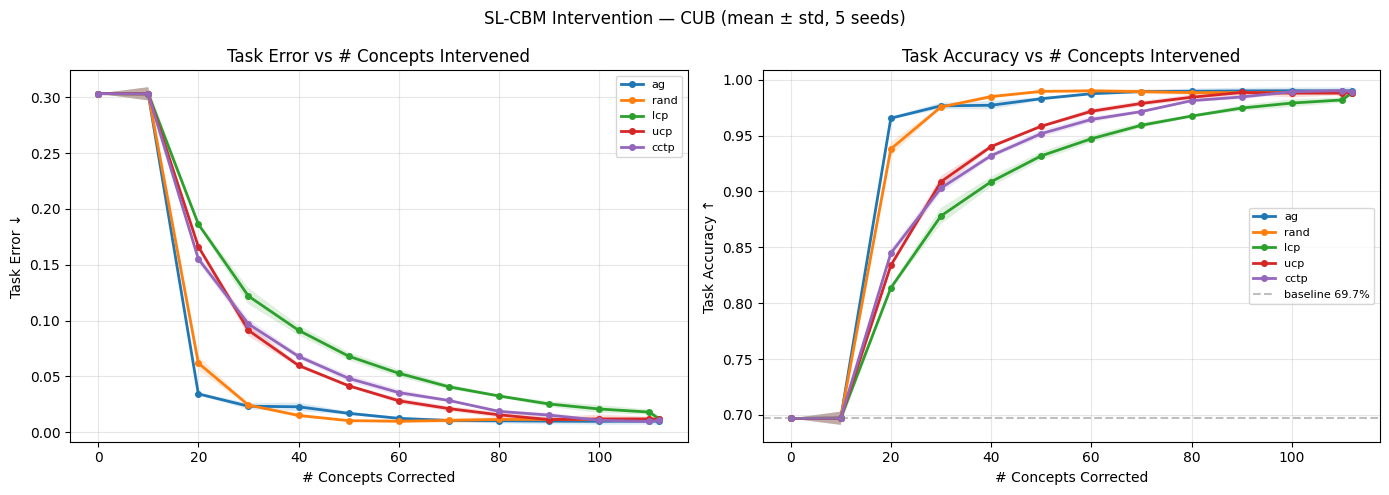

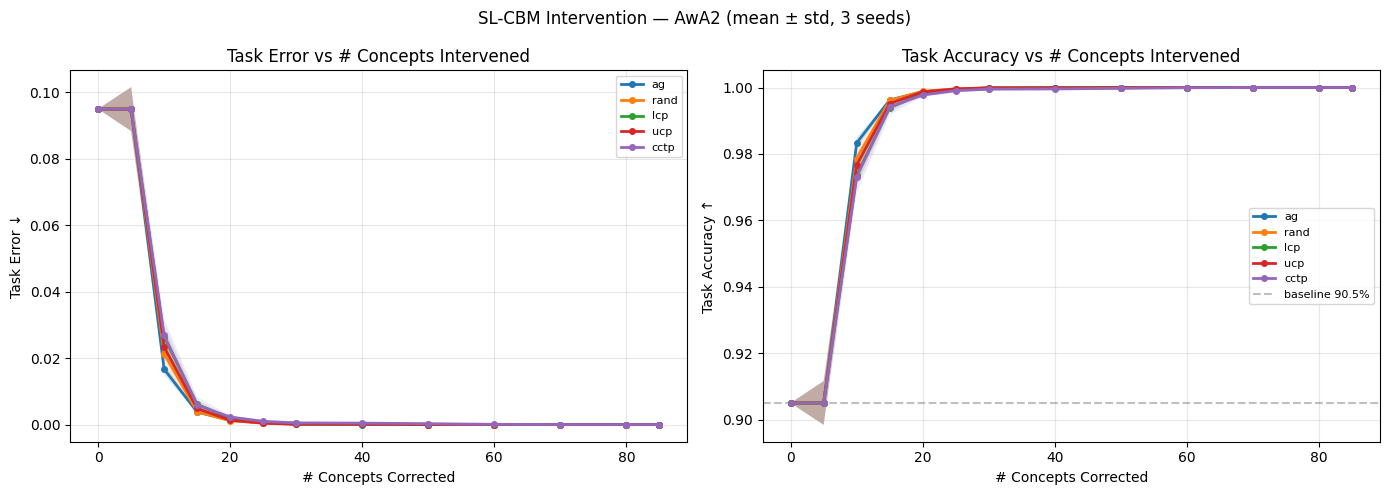

In [4]:
import matplotlib.pyplot as plt

CUB_STEPS  = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 112]
AWA2_STEPS = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 85, 85]

def load_intervention(exp_name):
    try:
        return torch.load(f"{BASE}/{exp_name}/evaluations/intervention_taskerror.pt", map_location="cpu")
    except FileNotFoundError:
        return None

def plot_intervention(seeds, exp_prefix, steps, title, baseline_accs):
    all_intervs = [load_intervention(f"{exp_prefix}{s}") for s in seeds]
    all_intervs = [(s, iv) for s, iv in zip(seeds, all_intervs) if iv is not None]
    if not all_intervs:
        print(f"No intervention data for {exp_prefix}")
        return

    methods = list(all_intervs[0][1].keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    baseline_error = 1.0 - np.mean(baseline_accs) / 100.0

    for method in methods:
        # collect per-seed curves
        curves = []
        for s, iv in all_intervs:
            t = iv[method]
            if not isinstance(t, torch.Tensor): continue
            y = t.mean(dim=0).numpy() if t.dim() == 2 else t.numpy()
            curves.append(np.concatenate([[baseline_error], y]))

        if not curves: continue
        min_len = min(len(c) for c in curves)
        curves = np.array([c[:min_len] for c in curves])
        mean_err = curves.mean(axis=0)
        std_err  = curves.std(axis=0)
        x = steps[:min_len]

        axes[0].plot(x, mean_err, label=method, linewidth=2, marker="o", markersize=4)
        axes[0].fill_between(x, mean_err - std_err, mean_err + std_err, alpha=0.15)
        axes[1].plot(x, 1 - mean_err, label=method, linewidth=2, marker="o", markersize=4)
        axes[1].fill_between(x, 1-(mean_err+std_err), 1-(mean_err-std_err), alpha=0.15)

    axes[0].set_title("Task Error vs # Concepts Intervened")
    axes[0].set_xlabel("# Concepts Corrected")
    axes[0].set_ylabel("Task Error ↓")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Task Accuracy vs # Concepts Intervened")
    axes[1].set_xlabel("# Concepts Corrected")
    axes[1].set_ylabel("Task Accuracy ↑")
    axes[1].axhline(y=np.mean(baseline_accs)/100, color="gray", linestyle="--",
                    alpha=0.5, label=f"baseline {np.mean(baseline_accs):.1f}%")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{BASE}/{exp_prefix.rstrip('_')}_intervention_multiseed.png", dpi=150, bbox_inches="tight")
    plt.show()

cub_baselines  = [r["class_acc"] for r in cub_results]
awa2_baselines = [r["class_acc"] for r in awa2_results]

plot_intervention(CUB_SEEDS,  "slcbm_cub_seed",  CUB_STEPS,
                  "SL-CBM Intervention — CUB (mean ± std, 5 seeds)", cub_baselines)
plot_intervention(AWA2_SEEDS, "slcbm_awa2_seed", AWA2_STEPS,
                  "SL-CBM Intervention — AwA2 (mean ± std, 3 seeds)", awa2_baselines)